## SetFit Batch Trigram Frequency Evaluation

#### Load Python Libraries

In [12]:
import pandas as pd
import re
from bs4 import BeautifulSoup
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
tqdm.pandas()

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

import mlflow

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jvhua\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jvhua\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jvhua\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#### Set Experiment

In [13]:
mlflow.set_experiment("adeptID")

<Experiment: artifact_location='file:///c:/Users/jvhua/OneDrive/Desktop/ISYE-CSE-MGT-6748-Group-1/02_preprocess/mlruns/418082982984917409', creation_time=1719438288344, experiment_id='418082982984917409', last_update_time=1719438288344, lifecycle_stage='active', name='adeptID', tags={}>

#### Helper Functions

In [14]:
def is_english_word(word):
    return wordnet.synsets(word)

def process_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    
    text = text.lower()
    
    text = re.sub(r'(\d+\.\d+)', r' \1 ', text)
    
    text = re.sub(r'[^a-z0-9\s.]', '', text)
    
    tokens = word_tokenize(text)
    
    processed_tokens = []
    for token in tokens:
        if (token.replace('.', '', 1).isdigit() or is_english_word(token)) and token not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(token))
    
    return processed_tokens

def plot_count(tokens, n_grams):
  vectorizer = CountVectorizer(ngram_range=n_grams)
  X = vectorizer.fit_transform(tokens)

  ngram_counts = X.sum(axis=0)

  ngram_freq = [(ngram, ngram_counts[0, idx]) for ngram, idx in vectorizer.vocabulary_.items()]
  sorted_ngrams = sorted(ngram_freq, key=lambda x: x[1], reverse=True)
  top_20_words = [word for word, count in sorted_ngrams[:20]]
  top_20_counts = [count for word, count in sorted_ngrams[:20]]

  plt.figure(figsize=(12, 6))
  sns.barplot(x=top_20_counts, y=top_20_words, color='lightblue')
  plt.title('Top 20 Words Bar Plot')
  plt.xlabel('Count')
  plt.ylabel('Word')
  plt.show()

  return plt.gcf()

#### Load in Data

In [10]:
df = pd.read_csv(r"C:\Users\jvhua\OneDrive\Desktop\ISYE-CSE-MGT-6748-Group-1\data\version2_setfit_filter_data_batch11.csv", index_col = 0)
df['text'] = df['signals_text'].progress_apply(lambda text: BeautifulSoup(text, 'html.parser').get_text())
df['tokens'] = df['text'].progress_apply(lambda text: process_text(text))
df['token'] = df['tokens'].apply(lambda x: " ".join(x))

  0%|          | 0/997 [00:00<?, ?it/s]C:\Users\jvhua\AppData\Local\Temp\ipykernel_9980\1150825628.py:2: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  df['text'] = df['signals_text'].progress_apply(lambda text: BeautifulSoup(text, 'html.parser').get_text())
100%|██████████| 997/997 [00:11<00:00, 85.72it/s] 


#### Create Visual Trigram

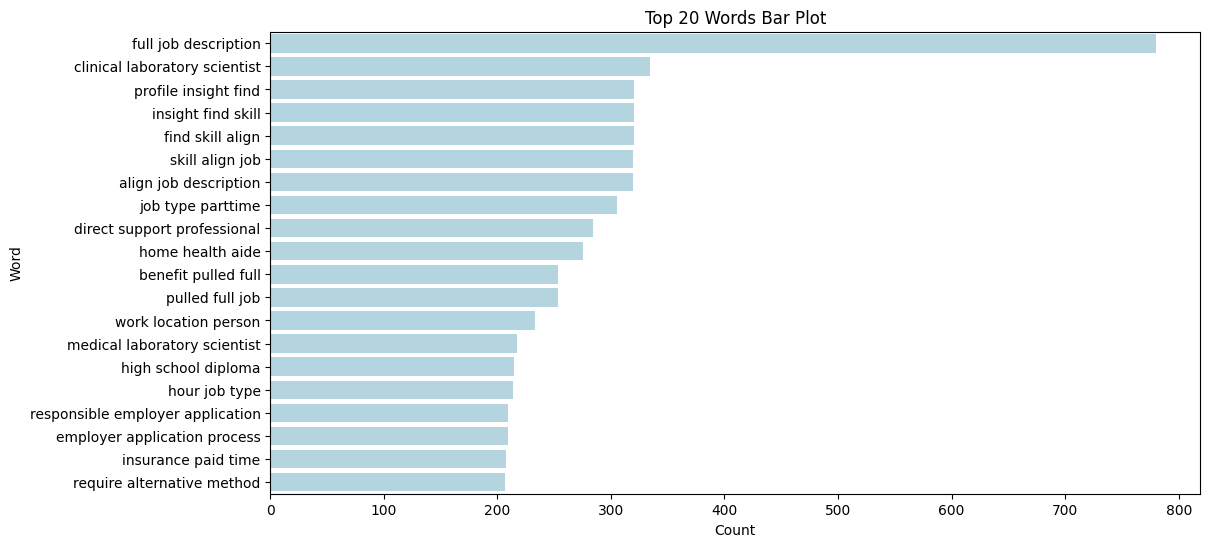

<Figure size 640x480 with 0 Axes>

In [15]:
plot_figure = plot_count(df['token'], (3,3))
mlflow.log_figure(plot_figure, 'batch_plot_trigram.png')

In [16]:
mlflow.end_run()